In [1]:
import matplotlib.pyplot as plt
from nibabel.freesurfer import read_annot
from matplotlib.colors import LinearSegmentedColormap
from nilearn import plotting, datasets

In [2]:
def load_annot(annot_left: str, annot_right: str, name: str = '') -> dict:

    '''
    Load the freesurfer annot file into a dictionary:
    atlas
        - left: left hemisphere
            - rois: contains the array of roi labels per each vertex in the reference mesh
            - colours: array of RGB colour values per region defined in atlas above
            - labels: list of text labels per region
            - cmap: matplotlib colourmap generated from the colours
        - right 
            ...
    '''

    keys = ["rois", "colours", "labels"]
    atlas = {
        "left": {key: value for key, value in zip(keys, read_annot(annot_left))},
        "right": {key: value for key, value in zip(keys, read_annot(annot_right))},
    }

    for hemi, obj in atlas.items():
        colours = obj["colours"][:, :-2] / 255
        colours[0, :] = 1
        obj["cmap"] = LinearSegmentedColormap.from_list(
            name=hemi, colors=colours, N=colours.shape[0]
        )

    atlas['name'] = name
    return atlas

# Load the annotation files

- `fsaverage3`: the low-resolution fsaverage3 mesh (642 nodes)
- `fsaverage4`: the low-resolution fsaverage4 mesh (2562 nodes)
- `fsaverage5`: the low-resolution fsaverage5 mesh (10242 nodes)
- `fsaverage6`: the medium-resolution fsaverage6 mesh (40962 nodes)
- `fsaverage7`: same as fsaverage
- `fsaverage`: the high-resolution fsaverage mesh (163842 nodes)

In [9]:
resolution = 'fsaverage'
fsaverage = datasets.fetch_surf_fsaverage(mesh=resolution)

# Schaefer
annot_lh = f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/lh.Schaefer2018_400Parcels_7Networks_order.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/data/external/schaefer/{resolution}/rh.Schaefer2018_400Parcels_7Networks_order.annot'
schaefer = load_annot(annot_lh, annot_rh, name='Schaefer')

# Yeo networks. only available in fsaverage5 - change resolution if this is necessary
annot_lh = f'/RAID1/jupytertmp/mcm/data/external/yeo/lh.Yeo2011_7Networks_N1000.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/data/external/yeo/rh.Yeo2011_7Networks_N1000.annot'
yeo = load_annot(annot_lh, annot_rh, name='Yeo')

# Glasser
annot_lh = '/RAID1/jupytertmp/mcm/data/external/hcp_mmp/lh.HCP-MMP1.annot'
annot_rh = '/RAID1/jupytertmp/mcm/data/external/hcp_mmp/rh.HCP-MMP1.annot'
glasser = load_annot(annot_lh, annot_rh, name='Glasser')

# Yan 2023 homotopic
annot_lh = f'/RAID1/jupytertmp/mcm/data/external/yan2023/parcellations/FreeSurfer/{resolution}/label/yeo7/lh.400Parcels_Yeo2011_7Networks.annot'
annot_rh = f'/RAID1/jupytertmp/mcm/data/external/yan2023/parcellations/FreeSurfer/{resolution}/label/yeo7/rh.400Parcels_Yeo2011_7Networks.annot'
yan = load_annot(annot_lh, annot_rh, name='Yan2023')

# Make the brain surfaces

see nilearn's [plot_surf_roi](https://nilearn.github.io/dev/modules/generated/nilearn.plotting.plot_surf_roi.html) documentation

Saved figure to: ./hemi-right_view-lateral_res-fsaverage_parcellation-Schaefer.png
Saved figure to: ./hemi-right_view-medial_res-fsaverage_parcellation-Schaefer.png


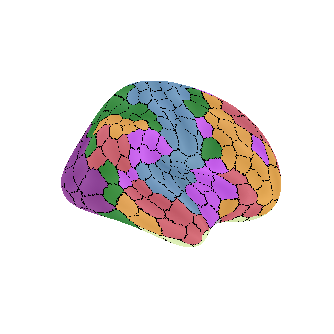

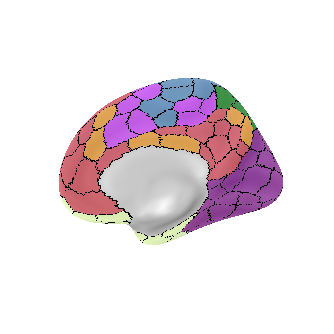

In [11]:
hemi = 'right' # plot only the right hemisphere
atlas = schaefer # or, yeo or glasser

for view in ['lateral', 'medial']: # 'dorsal', 'ventral', 'anterior', 'posterior'

    fig, ax = plt.subplots(1,1, subplot_kw={'projection': '3d'}, constrained_layout=True, figsize=(1,1), dpi=300)

    plotting.plot_surf_roi(
        surf_mesh=fsaverage[f'infl_{hemi}'], 
        roi_map=atlas[hemi]['rois'], 
        bg_map=fsaverage[f'sulc_{hemi}'], 
        hemi=hemi, 
        view=view, 
        cmap=atlas[hemi]['cmap'], 
        darkness=0.5,
        bg_on_data=True,
        axes=ax, 
        figure=fig
    )

    # draw the outline of the regions
    plotting.plot_surf_contours(
        surf_mesh=fsaverage[f'infl_{hemi}'], 
        roi_map=atlas[hemi]['rois'],
        colors=['k'] * len(atlas[hemi]['colours']),
        axes=ax,
        figure=fig
    )

    # save the figure
    filename = f'./hemi-{hemi}_view-{view}_res-{resolution}_parcellation-{atlas['name']}.png'
    fig.savefig(
        filename,
        dpi=300,
        transparent=True,
        bbox_inches='tight'
    )

    print(f'Saved figure to: {filename}')